In [16]:
import numpy as np, cv2
import matplotlib.pyplot as plt

## 6.1 화소 (행렬 원소) 접근

In [13]:
def mat_access(mat):
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            k = mat[i, j]
            mat[i, j] = k * 2

def _mat_access(mat):
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            k = mat.item(i, j)
            mat[i, j] = k * 2

m1 = np.arange(10).reshape(2, 5)
m2 = np.arange(10).reshape(2, 5)

print("%s = \n%s \n" % ("m1", m1))
print("%s = \n%s \n" % ("m2", m2))

mat_access(m1)
_mat_access(m2)

print("%s = \n%s \n" % ("m1", m1))
print("%s = \n%s \n" % ("m2", m2))

m1 = 
[[0 1 2 3 4]
 [5 6 7 8 9]] 

m2 = 
[[0 1 2 3 4]
 [5 6 7 8 9]] 

m1 = 
[[ 0  2  4  6  8]
 [10 12 14 16 18]] 

m2 = 
[[ 0  2  4  6  8]
 [10 12 14 16 18]] 



가장 원소에 빠르게 접근하는 법이 코드상에 나오는데 목적은 OpenCV 함수나 numpy 함수 이용시 더 속도가 빠르다는 것이다.

In [ ]:
# 룩업 테이블을 이용한 접근
def pixel_access3(image):
    lut = [255-i for i in range(256)]
    lut = np.array(lut, np.uint8)
    image3 = lut[image]
    return image

# OpenCV 함수를 이용한 접근
def pixel_access4(img):
    img4 = cv.subtract(255, image)
    return img4

# ndarray 산술 연산 방법
def pixel_access5(img):
    img5 = 255 - img
    return img5

image = cv.imread("../images/timetable.jpg", cv2.IMREAD_GRAYSCALE)

## 6.2 화소 밝기 변환

단일 채널의 영상을 그레이 스케일이라 하며 명암도 영상이라고도 하고 화소값은 0 - 255를 가지는데 검은색(0)에서 흰색으로 구성된다.

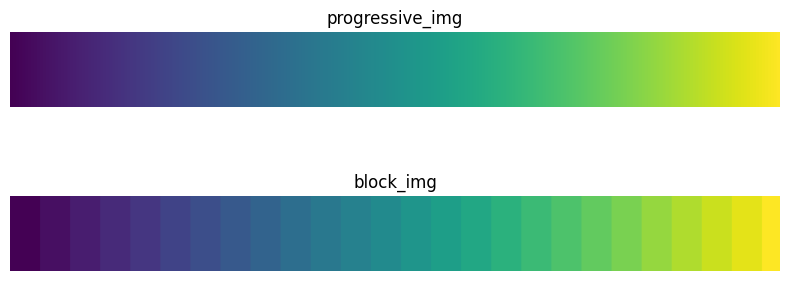

In [22]:
progressive_img = np.zeros((50, 512), np.uint8)
block_img = np.zeros((50, 512), np.uint8)
rows, cols = progressive_img.shape[:2]

for i in range(rows):
    for j in range(cols):
        progressive_img[i, j] = j // 2
        block_img[i, j] = j // 20 * 10

titles = ['progressive_img', 'block_img']

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(8, 4))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title))
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

직접 파일에서 특정 영역 화소 불러오기

shape:  (6720, 3780)
 143  142  141  140  139  138  137  136  135  135  136  136  136  136  137 
 145  144  142  141  140  139  138  136  135  135  135  135  134  135  136 
 144  142  140  139  141  140  138  136  135  134  134  134  133  133  134 
 139  138  138  137  135  138  139  138  134  133  134  137  136  139  141 
 140  139  138  138  137  139  140  139  136  134  136  138  136  139  142 
 141  140  140  139  139  140  141  140  138  137  138  139  136  139  142 
 141  141  140  140  141  141  142  141  141  140  141  141  137  140  143 
 140  140  141  141  142  142  142  142  143  143  143  142  140  141  143 
 139  140  140  140  143  142  141  142  144  144  144  142  144  143  142 
 137  138  139  139  143  141  140  141  144  145  144  142  147  144  142 



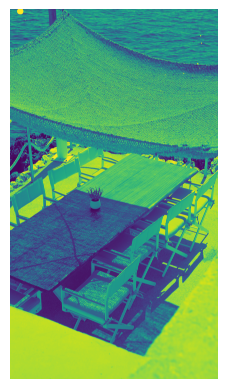

In [36]:
img = cv2.imread("../images/bench.jpg", cv2.IMREAD_GRAYSCALE)
print("shape: ", img.shape[:2])

(x, y), (w, h) = (180, 37), (15, 10)
roi_img = img[y:y+h, x:x+w]

for r in roi_img:
    for p in r:
        print("%4d" % p, end=" ")
    print()

print()

cv2.rectangle(img, (x, y, w, h), 255, 100)
plt.imshow(img)
plt.axis("off")
plt.show()

화소 값을 줄이거나 올려서 밝기를 올리고 싶다! => cv2. add, subtract() or numpy에서 연산을 이용하면 되는데 OpenCV는 saturation 연산으로 255를 넘으면 그냥 255가 되지만 numpy에서는 modulo 방식을 사용하기 때문에 340 이라면 340 % 255 = 104가 밝기가 된다.

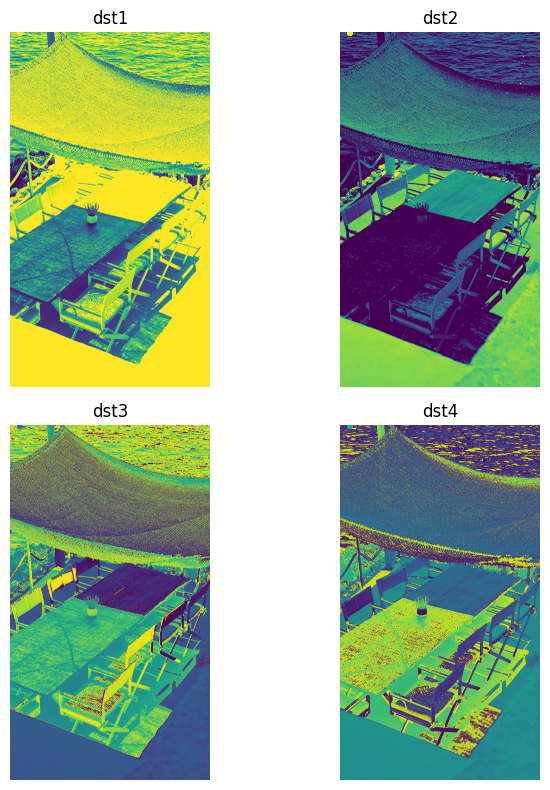

In [37]:
# OpenCV function
dst1 = cv2.add(img, 100)
dst2 = cv2.subtract(img, 100)

# numpy function
dst3 = img + 100
dst4 = img - 100

titles = ['dst1', 'dst2', 'dst3', 'dst4']

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title))
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

상수가 아닌 이미지 두 개를 더하거나 빼면 어떻게 될까?
그리고 둘을 더한다면 saturation() 연산이면 하얀색으로만 화면이 가득 찰 것이다. 그것을 alpha, beta 가중치를 주어 해결한다.

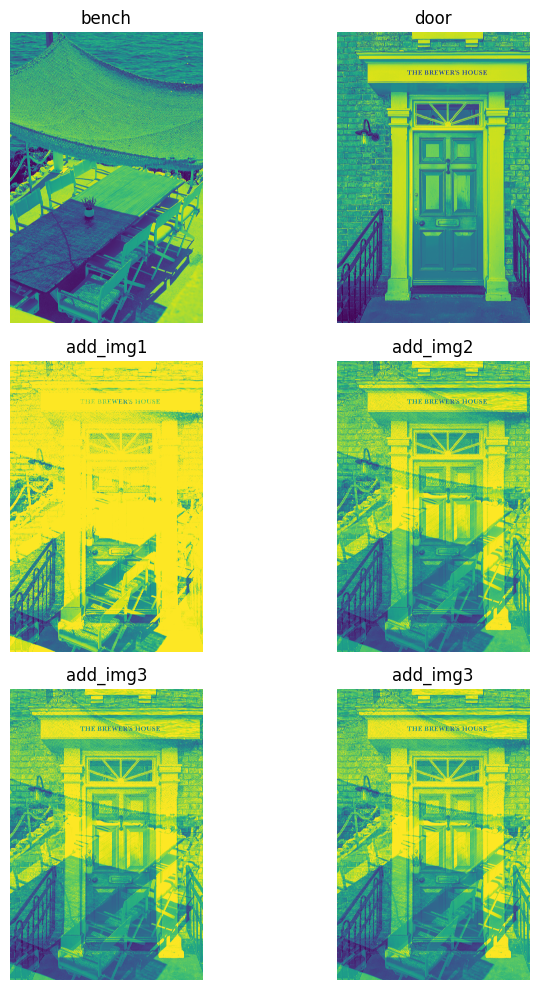

In [52]:
bench = cv2.imread("../images/bench.jpg", cv2.IMREAD_GRAYSCALE)
door = cv2.imread("../images/door.jpg", cv2.IMREAD_GRAYSCALE)

bench = bench[:5712]
door = door[:,:3780]
# print(bench.shape[:2], door.shape[:2])

alpha, beta = 0.6, 0.7
add_img1 = cv2.add(bench, door)
add_img2 = cv2.add(bench * alpha, door * beta)
add_img2 = np.clip(add_img2, 0, 255).astype("uint8")
add_img3 = cv2.addWeighted(bench, alpha, door, beta, 0)

titles = ['bench', 'door', 'add_img1', 'add_img2', 'add_img3', 'add_img3']

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(8, 10))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title))
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

명암 대비는 상이한 두 가지 색(밝기)이 경계에서 서로 영향을 미쳐 그 차이가 강조되어 나타나는 현상을 말한다. 명암 대비가 크면 영상이 또렷해보이고 반대의 경우에는 영상이 밝거나 어둡다.
그렇다면 이러한 명암 대비를 조절하기 위해서는 어두운 부분을 더 어둡게 밝은 부분을 더 밝게 만들어 주면 되므로 늘리기 위해서는 어떤 수를 기준으로 1.0 초과의 값을 곱해주면 되고 반대로 줄이기 위해서는 1.0 미만의 값을 곱해주면 된다.

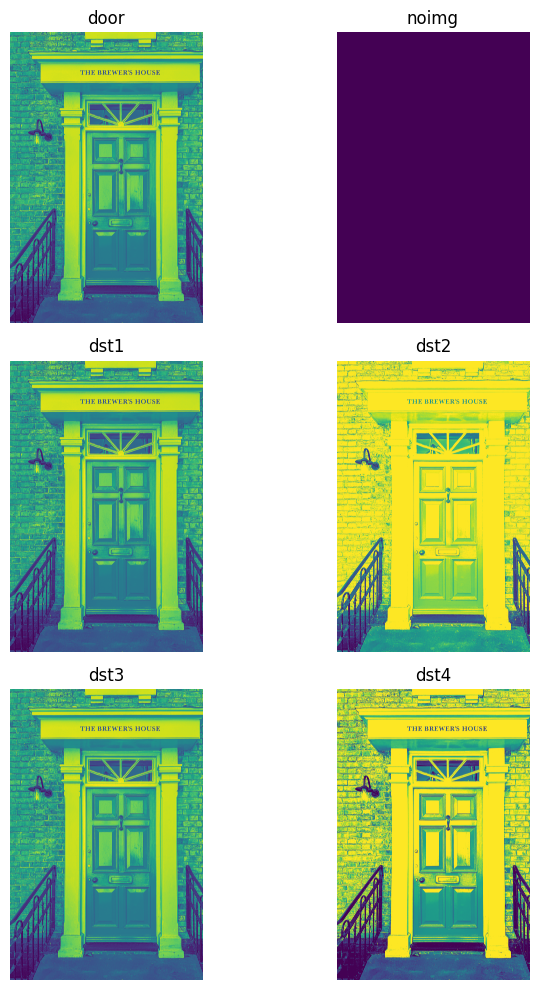

In [53]:
noimg = np.zeros(door.shape[:2], door.dtype)
avg = cv2.mean(door)[0]/2.0

dst1 = cv2.scaleAdd(door, 0.5, noimg)
dst2 = cv2.scaleAdd(door, 2, noimg)
dst3 = cv2.addWeighted(door, 0.5, noimg, 0, avg)
dst4 = cv2.addWeighted(door, 2.0, noimg, 0, -avg)

titles = ['door', 'noimg', 'dst1', 'dst2', 'dst3', 'dst4']

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(8, 10))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title))
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()
